In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import joblib
import json
import os

In [2]:
data_path = (
    "../../data/processed/"
    "raipur_5year_processed.csv"
)

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (12500, 16)


,longitude,latitude,Year,LST,NDVI,NDBI,NDWI,location_id,LST_change,NDVI_change,NDBI_change,NDWI_change,LST_from_2022,NDVI_from_2022,NDBI_from_2022,NDWI_from_2022
0,81.633354,21.118583,2022,47.385043,0.144367,0.070714,-0.191317,21.118583_81.633354,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
1,81.633354,21.118583,2023,48.783013,0.090909,0.025947,-0.122160,21.118583_81.633354,1.397970,-0.053457,-0.044768,0.069158,1.397970,-0.053457,-0.044768,0.069158
2,81.633354,21.118583,2024,56.919609,0.113913,0.072583,-0.159775,21.118583_81.633354,8.136597,0.023004,0.046637,-0.037615,9.534567,-0.030454,0.001869,0.031542
3,81.633354,21.118583,2025,39.979902,0.112862,0.072756,-0.155619,21.118583_81.633354,-16.939707,-0.001051,0.000173,0.004157,-7.405140,-0.031504,0.002042,0.035699
4,81.633354,21.118583,2026,49.784493,0.098629,0.083194,-0.139808,21.118583_81.633354,9.804590,-0.014233,0.010438,0.015811,2.399450,-0.045738,0.012479,0.051510


In [3]:
print(
    df["Year"]
    .value_counts()
    .sort_index()
)

Year
2022    2500
2023    2500
2024    2500
2025    2500
2026    2500
Name: count, dtype: int64


In [4]:
train_df = df[
    df["Year"] < 2026
].copy()

test_df = df[
    df["Year"] == 2026
].copy()

print(
    "Training samples:",
    len(train_df)
)

print(
    "Testing samples:",
    len(test_df)
)

Training samples: 10000
Testing samples: 2500


In [5]:
environmental_features = [
    "NDVI",
    "NDBI",
    "NDWI"
]

spatial_features = [
    "NDVI",
    "NDBI",
    "NDWI",
    "latitude",
    "longitude"
]

full_features = [
    "NDVI",
    "NDBI",
    "NDWI",
    "latitude",
    "longitude",
    "Year"
]

target = "LST"

In [6]:
X_train_env = train_df[
    environmental_features
]

X_test_env = test_df[
    environmental_features
]

X_train_spatial = train_df[
    spatial_features
]

X_test_spatial = test_df[
    spatial_features
]

X_train_full = train_df[
    full_features
]

X_test_full = test_df[
    full_features
]

y_train = train_df[target]
y_test = test_df[target]

In [7]:
def evaluate_model(name, y_true, predictions):

    mae = mean_absolute_error(
        y_true,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            predictions
        )
    )

    r2 = r2_score(
        y_true,
        predictions
    )

    print(f"\n{name}")
    print("-" * len(name))
    print(f"MAE  : {mae:.4f} °C")
    print(f"RMSE : {rmse:.4f} °C")
    print(f"R²   : {r2:.4f}")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [8]:
rf_env = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_env.fit(
    X_train_env,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [9]:
rf_env_pred = rf_env.predict(
    X_test_env
)

In [10]:
rf_env_results = evaluate_model(
    "Random Forest - Environmental",
    y_test,
    rf_env_pred
)


Random Forest - Environmental
-----------------------------
MAE  : 2.1803 °C
RMSE : 2.6905 °C
R²   : 0.2214


In [11]:
xgb_env = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_env.fit(
    X_train_env,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [12]:
xgb_env_pred = xgb_env.predict(
    X_test_env
)

In [13]:
xgb_env_results = evaluate_model(
    "XGBoost - Environmental",
    y_test,
    xgb_env_pred
)


XGBoost - Environmental
-----------------------
MAE  : 1.9837 °C
RMSE : 2.4461 °C
R²   : 0.3564


In [14]:
rf_spatial = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_spatial.fit(
    X_train_spatial,
    y_train
)

rf_spatial_pred = rf_spatial.predict(
    X_test_spatial
)

In [15]:
rf_spatial_results = evaluate_model(
    "Random Forest - Environmental + Spatial",
    y_test,
    rf_spatial_pred
)


Random Forest - Environmental + Spatial
---------------------------------------
MAE  : 2.2055 °C
RMSE : 2.6739 °C
R²   : 0.2310


In [16]:
rf_full = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_full.fit(
    X_train_full,
    y_train
)

rf_full_pred = rf_full.predict(
    X_test_full
)

In [17]:
rf_full = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_full.fit(
    X_train_full,
    y_train
)

rf_full_pred = rf_full.predict(
    X_test_full
)

In [18]:
rf_full_results = evaluate_model(
    "Random Forest - Full",
    y_test,
    rf_full_pred
)


Random Forest - Full
--------------------
MAE  : 5.0786 °C
RMSE : 5.7588 °C
R²   : -2.5669


In [19]:
results = pd.DataFrame([
    rf_env_results,
    xgb_env_results,
    rf_spatial_results,
    rf_full_results
])

results

,Model,MAE,RMSE,R2
0,Random Forest - Environmental,2.180277,2.690495,0.221442
1,XGBoost - Environmental,1.983683,2.446149,0.356435
2,Random Forest - Environmental + Spatial,2.205528,2.673914,0.231009
3,Random Forest - Full,5.078567,5.758804,-2.566900


In [20]:
final_model = xgb_env

final_features = environmental_features

final_predictions = xgb_env_pred

print("Final model: XGBoost Regressor")
print("Features:", final_features)

Final model: XGBoost Regressor
Features: ['NDVI', 'NDBI', 'NDWI']


In [21]:
final_mae = mean_absolute_error(
    y_test,
    final_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_predictions
    )
)

final_r2 = r2_score(
    y_test,
    final_predictions
)

print("FINAL MODEL")
print("===========")

print(
    f"MAE  : {final_mae:.4f} °C"
)

print(
    f"RMSE : {final_rmse:.4f} °C"
)

print(
    f"R²   : {final_r2:.4f}"
)

FINAL MODEL
MAE  : 1.9837 °C
RMSE : 2.4461 °C
R²   : 0.3564


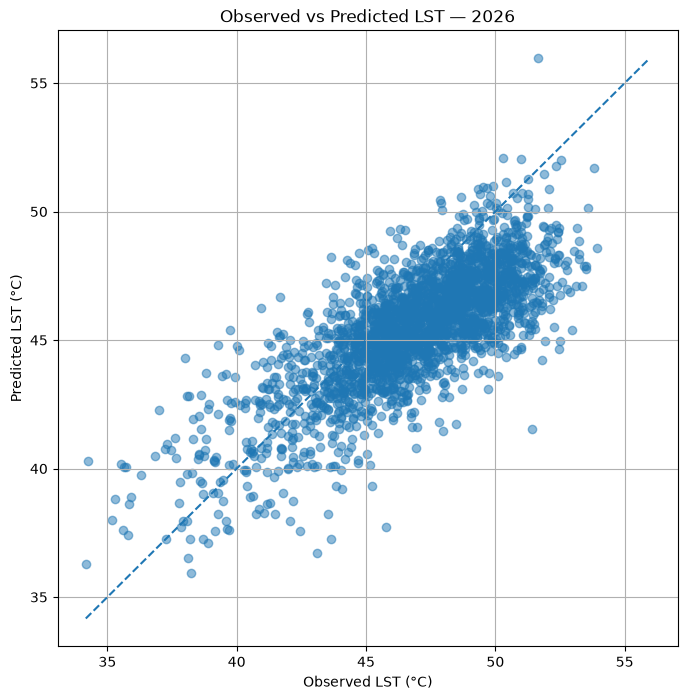

In [22]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.5
)

min_value = min(
    y_test.min(),
    final_predictions.min()
)

max_value = max(
    y_test.max(),
    final_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel(
    "Observed LST (°C)"
)

plt.ylabel(
    "Predicted LST (°C)"
)

plt.title(
    "Observed vs Predicted LST — 2026"
)

plt.grid(True)

plt.show()

In [23]:
residuals = (
    y_test - final_predictions
)

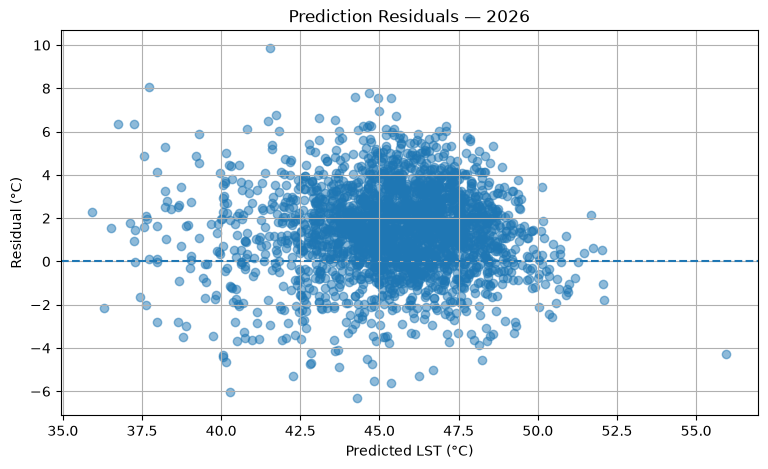

In [24]:
plt.figure(figsize=(9, 5))

plt.scatter(
    final_predictions,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel(
    "Predicted LST (°C)"
)

plt.ylabel(
    "Residual (°C)"
)

plt.title(
    "Prediction Residuals — 2026"
)

plt.grid(True)

plt.show()

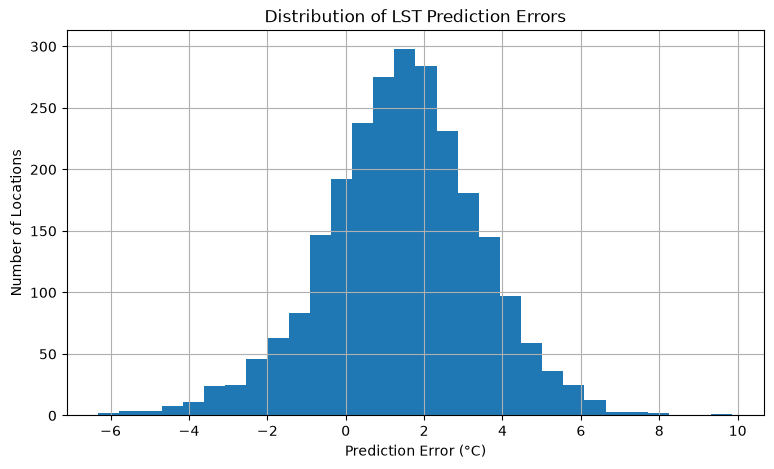

In [25]:
plt.figure(figsize=(9, 5))

plt.hist(
    residuals,
    bins=30
)

plt.xlabel(
    "Prediction Error (°C)"
)

plt.ylabel(
    "Number of Locations"
)

plt.title(
    "Distribution of LST Prediction Errors"
)

plt.grid(True)

plt.show()

In [26]:
importance = pd.DataFrame({
    "Feature": final_features,
    "Importance": final_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,NDBI,0.533293
0,NDVI,0.269820
2,NDWI,0.196887


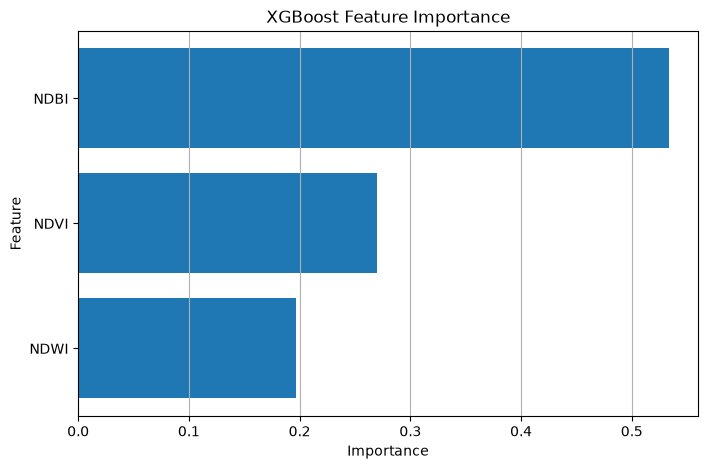

In [27]:
plt.figure(figsize=(8, 5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "XGBoost Feature Importance"
)

plt.gca().invert_yaxis()

plt.grid(axis="x")

plt.show()

In [28]:
os.makedirs(
    "../models",
    exist_ok=True
)

In [29]:
model_path = (
    "../models/"
    "final_first_xgboost_environmental.pkl"
)

joblib.dump(
    final_model,
    model_path
)

print(
    f"Model saved to: {model_path}"
)

Model saved to: ../models/final_first_xgboost_environmental.pkl


In [31]:
metadata = {
    "model_type": "XGBoost Regressor",
    "features": final_features,
    "target": "LST",
    "training_years": [
        2022,
        2023,
        2024,
        2025
    ],
    "test_year": 2026,
    "mae": float(final_mae),
    "rmse": float(final_rmse),
    "r2": float(final_r2)
}

metadata_path = (
    "../models/"
    "final_first_xgboost_environmental_metadata.json"
)

with open(
    metadata_path,
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )

print(
    f"Metadata saved to: {metadata_path}"
)

Metadata saved to: ../models/final_first_xgboost_environmental_metadata.json


In [32]:
prediction_map = test_df[
    [
        "longitude",
        "latitude",
        "Year",
        "LST",
        "NDVI",
        "NDBI",
        "NDWI"
    ]
].copy()

prediction_map = prediction_map.rename(
    columns={
        "LST": "observed_LST"
    }
)

prediction_map[
    "predicted_LST"
] = final_predictions

prediction_map[
    "prediction_error"
] = (
    prediction_map["observed_LST"]
    - prediction_map["predicted_LST"]
)

In [33]:
prediction_map.head()

,longitude,latitude,Year,observed_LST,NDVI,NDBI,NDWI,predicted_LST,prediction_error
4,81.633354,21.118583,2026,49.784493,0.098629,0.083194,-0.139808,50.603085,-0.818592
9,81.621632,21.118771,2026,52.371934,0.096673,0.076885,-0.142427,48.945923,3.426011
14,81.621544,21.119428,2026,52.474474,0.093956,0.079217,-0.138296,49.379753,3.094721
19,81.628593,21.119945,2026,51.478122,0.120403,0.069468,-0.173738,47.358128,4.119994
24,81.625616,21.120315,2026,53.139279,0.097107,0.080233,-0.139321,49.366962,3.772317


In [34]:
prediction_path = (
    "../../data/processed/"
    "raipur_2026_predictions.csv"
)

prediction_map.to_csv(
    prediction_path,
    index=False
)

print(
    f"Saved predictions to: {prediction_path}"
)

Saved predictions to: ../../data/processed/raipur_2026_predictions.csv
